In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
file_path = "/content/Data (1).csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [ ]:
print("Shape of dataset:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

Shape of dataset:
(377719, 7)

Column names:
['time', 'Cyclone_Inlet_Gas_Temp', 'Cyclone_Material_Temp', 'Cyclone_Outlet_Gas_draft', 'Cyclone_cone_draft', 'Cyclone_Gas_Outlet_Temp', 'Cyclone_Inlet_Draft']


In [ ]:
df.head(10)

,time,Cyclone_Inlet_Gas_Temp,Cyclone_Material_Temp,Cyclone_Outlet_Gas_draft,Cyclone_cone_draft,Cyclone_Gas_Outlet_Temp,Cyclone_Inlet_Draft
0,01-01-2017 00:00,867.63,910.42,-189.54,-186.04,852.13,-145.9
1,01-01-2017 00:05,879.23,918.14,-184.33,-182.1,862.53,-149.76
2,01-01-2017 00:10,875.67,924.18,-181.26,-166.47,866.06,-145.01
3,01-01-2017 00:15,875.28,923.15,-179.15,-174.83,865.85,-142.82
4,01-01-2017 00:20,891.66,934.26,-178.32,-173.72,876.06,-143.39
5,01-01-2017 00:25,878.54,932.38,-188.37,-177.98,870.31,-146.92
6,01-01-2017 00:30,905.94,951.32,-184.2,-182.67,889.39,-151.83
7,01-01-2017 00:35,877.83,939.63,-184.2,-181.17,875.75,-149.7
8,01-01-2017 00:40,871.01,938.73,-184.2,-181.17,871.35,-145.62
9,01-01-2017 00:45,905.46,939.06,-182.63,-178.23,871.35,-148.88


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 377719 entries, 0 to 377718
Data columns (total 7 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   time                      377719 non-null  object
 1   Cyclone_Inlet_Gas_Temp    377719 non-null  object
 2   Cyclone_Material_Temp     377719 non-null  object
 3   Cyclone_Outlet_Gas_draft  377719 non-null  object
 4   Cyclone_cone_draft        377719 non-null  object
 5   Cyclone_Gas_Outlet_Temp   377719 non-null  object
 6   Cyclone_Inlet_Draft       377719 non-null  object
dtypes: object(7)
memory usage: 20.2+ MB


In [ ]:
missing_values = df.isnull().sum()

print(missing_values)

time                        0
Cyclone_Inlet_Gas_Temp      0
Cyclone_Material_Temp       0
Cyclone_Outlet_Gas_draft    0
Cyclone_cone_draft          0
Cyclone_Gas_Outlet_Temp     0
Cyclone_Inlet_Draft         0
dtype: int64


In [ ]:
for column in df.columns:
    count = (df[column] == "Not Connect").sum()
    if count > 0:
        print(column, ":", count)

Cyclone_Inlet_Gas_Temp : 723
Cyclone_Material_Temp : 723
Cyclone_Outlet_Gas_draft : 723
Cyclone_cone_draft : 723
Cyclone_Gas_Outlet_Temp : 723
Cyclone_Inlet_Draft : 723


In [ ]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [ ]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
time                        227235
Cyclone_Inlet_Gas_Temp           0
Cyclone_Material_Temp            0
Cyclone_Outlet_Gas_draft         0
Cyclone_cone_draft               0
Cyclone_Gas_Outlet_Temp          0
Cyclone_Inlet_Draft              0
dtype: int64


In [ ]:
raw_time = pd.read_csv(file_path, usecols=["time"])["time"]

print("Total rows:", len(raw_time))
print("Original missing values:", raw_time.isna().sum())

print("\nFirst 10 raw timestamps:")
print(raw_time.head(10))

print("\nLast 10 raw timestamps:")
print(raw_time.tail(10))

print("\nUnique timestamp formats/examples:")
print(raw_time.astype(str).drop_duplicates().head(20).to_list())

Total rows: 377719
Original missing values: 0

First 10 raw timestamps:
0    01-01-2017 00:00
1    01-01-2017 00:05
2    01-01-2017 00:10
3    01-01-2017 00:15
4    01-01-2017 00:20
5    01-01-2017 00:25
6    01-01-2017 00:30
7    01-01-2017 00:35
8    01-01-2017 00:40
9    01-01-2017 00:45
Name: time, dtype: object

Last 10 raw timestamps:
377709    08-07-2020 11:30
377710    08-07-2020 11:35
377711    08-07-2020 11:40
377712    08-07-2020 11:45
377713    08-07-2020 11:50
377714    08-07-2020 11:55
377715    08-07-2020 12:00
377716    08-07-2020 12:05
377717    08-07-2020 12:10
377718    08-07-2020 12:15
Name: time, dtype: object

Unique timestamp formats/examples:
['01-01-2017 00:00', '01-01-2017 00:05', '01-01-2017 00:10', '01-01-2017 00:15', '01-01-2017 00:20', '01-01-2017 00:25', '01-01-2017 00:30', '01-01-2017 00:35', '01-01-2017 00:40', '01-01-2017 00:45', '01-01-2017 00:50', '01-01-2017 00:55', '01-01-2017 01:00', '01-01-2017 01:05', '01-01-2017 01:10', '01-01-2017 01:15', '01-

In [ ]:
raw_time = raw_time.astype(str).str.strip()

hyphen_mask = raw_time.str.match(r"^\d{2}-\d{2}-\d{4} \d{2}:\d{2}$")
slash_mask = raw_time.str.match(r"^\d{1,2}/\d{1,2}/\d{4} \d{1,2}:\d{2}$")

parsed_time = pd.Series(pd.NaT, index=raw_time.index, dtype="datetime64[ns]")

parsed_time.loc[hyphen_mask] = pd.to_datetime(
    raw_time.loc[hyphen_mask],
    format="%d-%m-%Y %H:%M",
    errors="coerce"
)

parsed_time.loc[slash_mask] = pd.to_datetime(
    raw_time.loc[slash_mask],
    format="%m/%d/%Y %H:%M",
    errors="coerce"
)

df["time"] = parsed_time

print("Hyphen-format timestamps:", hyphen_mask.sum())
print("Slash-format timestamps:", slash_mask.sum())
print("Unrecognized timestamps:", (~(hyphen_mask | slash_mask)).sum())
print("Missing timestamps after parsing:", df["time"].isna().sum())
print("Start time:", df["time"].min())
print("End time:", df["time"].max())

Hyphen-format timestamps: 150484
Slash-format timestamps: 227235
Unrecognized timestamps: 0
Missing timestamps after parsing: 0
Start time: 2017-01-01 00:00:00
End time: 2020-12-07 23:55:00


In [ ]:
time_diff = df["time"].diff()

print("Duplicate timestamps:", df["time"].duplicated().sum())
print("Out-of-order timestamps:", (time_diff < pd.Timedelta(0)).sum())
print("Expected 5-minute intervals:", (time_diff == pd.Timedelta(minutes=5)).sum())
print("Unexpected intervals:", ((time_diff != pd.Timedelta(minutes=5)) & time_diff.notna()).sum())

Duplicate timestamps: 0
Out-of-order timestamps: 80
Expected 5-minute intervals: 377156
Unexpected intervals: 562


In [ ]:
unexpected = time_diff[(time_diff != pd.Timedelta(minutes=5)) & time_diff.notna()]

print("Smallest interval:", unexpected.min())
print("Largest interval:", unexpected.max())

print("\nMost common unexpected intervals:")
print(unexpected.value_counts().head(10))

print("\nNegative intervals:", (unexpected < pd.Timedelta(0)).sum())
print("Intervals longer than 5 minutes:", (unexpected > pd.Timedelta(minutes=5)).sum())

Smallest interval: -324 days +00:05:00
Largest interval: 30 days 00:05:00

Most common unexpected intervals:
time
30 days 00:05:00       261
29 days 00:05:00       174
27 days 00:05:00        36
28 days 00:05:00         8
-323 days +00:05:00      6
-30 days +00:05:00       4
-207 days +00:05:00      4
-266 days +00:05:00      4
-148 days +00:05:00      4
-177 days +00:05:00      4
Name: count, dtype: int64

Negative intervals: 80
Intervals longer than 5 minutes: 482


In [ ]:
sensor_cols = [col for col in df.columns if col != "time"]

print("Sensor columns:")
print(sensor_cols)

print("\n'Not Connect' count:")
print((df[sensor_cols] == "Not Connect").sum())

print("\nZero count:")
print((df[sensor_cols] == 0).sum())

Sensor columns:
['Cyclone_Inlet_Gas_Temp', 'Cyclone_Material_Temp', 'Cyclone_Outlet_Gas_draft', 'Cyclone_cone_draft', 'Cyclone_Gas_Outlet_Temp', 'Cyclone_Inlet_Draft']

'Not Connect' count:
Cyclone_Inlet_Gas_Temp      723
Cyclone_Material_Temp       723
Cyclone_Outlet_Gas_draft    723
Cyclone_cone_draft          723
Cyclone_Gas_Outlet_Temp     723
Cyclone_Inlet_Draft         723
dtype: int64

Zero count:
Cyclone_Inlet_Gas_Temp      0
Cyclone_Material_Temp       0
Cyclone_Outlet_Gas_draft    0
Cyclone_cone_draft          0
Cyclone_Gas_Outlet_Temp     0
Cyclone_Inlet_Draft         0
dtype: int64


In [ ]:
# --- Sensor Connectivity: identify true time-contiguous episodes ---

nc = df.loc[not_connect_mask, ["time"]].copy()
nc["row_index"] = nc.index

# A new episode starts when either the row or timestamp is discontinuous
nc["new_episode"] = (
    nc["row_index"].diff().ne(1) |
    nc["time"].diff().ne(pd.Timedelta(minutes=5))
).fillna(True)

nc["episode"] = nc["new_episode"].cumsum()

true_episode_summary = nc.groupby("episode").agg(
    start_time=("time", "min"),
    end_time=("time", "max"),
    records=("time", "size")
)

true_episode_summary["duration"] = (
    true_episode_summary["end_time"] -
    true_episode_summary["start_time"]
)

print("True time-contiguous 'Not Connect' episodes:", len(true_episode_summary))
print("\nEpisode summary:")
print(true_episode_summary.to_string())

True time-contiguous 'Not Connect' episodes: 16

Episode summary:
                 start_time            end_time  records        duration
episode                                                                 
1       2017-03-10 11:20:00 2017-03-10 23:55:00      152 0 days 12:35:00
2       2017-04-10 00:00:00 2017-04-10 23:55:00      288 0 days 23:55:00
3       2017-05-10 00:00:00 2017-05-10 14:45:00      178 0 days 14:45:00
4       2017-10-10 11:45:00 2017-10-10 11:45:00        1 0 days 00:00:00
5       2017-10-19 12:10:00 2017-10-19 15:20:00       39 0 days 03:10:00
6       2017-10-19 15:30:00 2017-10-19 17:40:00       27 0 days 02:10:00
7       2017-10-20 11:40:00 2017-10-20 11:40:00        1 0 days 00:00:00
8       2017-10-20 14:00:00 2017-10-20 14:00:00        1 0 days 00:00:00
9       2017-10-20 14:10:00 2017-10-20 14:15:00        2 0 days 00:05:00
10      2017-10-20 14:30:00 2017-10-20 14:30:00        1 0 days 00:00:00
11      2019-03-13 11:25:00 2019-03-13 11:55:00        7 0

In [ ]:
# --- Convert sensor readings to numeric values ---

df_numeric = df.copy()

for col in sensor_cols:
    df_numeric[col] = pd.to_numeric(df_numeric[col], errors="coerce")

print("Sensor data types after conversion:")
print(df_numeric[sensor_cols].dtypes)

print("\nMissing values created by non-numeric entries:")
print(df_numeric[sensor_cols].isna().sum())

Sensor data types after conversion:
Cyclone_Inlet_Gas_Temp      float64
Cyclone_Material_Temp       float64
Cyclone_Outlet_Gas_draft    float64
Cyclone_cone_draft          float64
Cyclone_Gas_Outlet_Temp     float64
Cyclone_Inlet_Draft         float64
dtype: object

Missing values created by non-numeric entries:
Cyclone_Inlet_Gas_Temp      1320
Cyclone_Material_Temp       1591
Cyclone_Outlet_Gas_draft    1321
Cyclone_cone_draft          1320
Cyclone_Gas_Outlet_Temp     1321
Cyclone_Inlet_Draft         1322
dtype: int64


In [ ]:
# --- Investigate missing sensor readings ---

missing_mask = df_numeric[sensor_cols].isna()

rows_with_missing = missing_mask.any(axis=1)

print("Rows with at least one missing sensor:", rows_with_missing.sum())

print("\nRows where all six sensors are missing:", missing_mask.all(axis=1).sum())

print("\nMissing-sensor pattern:")
print(missing_mask.sum(axis=1).value_counts().sort_index())

Rows with at least one missing sensor: 1595

Rows where all six sensors are missing: 1320

Missing-sensor pattern:
0    376124
1       275
6      1320
Name: count, dtype: int64


In [ ]:
# --- Quantify usable process observations ---

all_missing_mask = df_numeric[sensor_cols].isna().all(axis=1)
partial_missing_mask = (
    df_numeric[sensor_cols].isna().any(axis=1)
    & ~all_missing_mask
)

usable_mask = ~df_numeric[sensor_cols].isna().any(axis=1)

print("Total records:", len(df_numeric))
print("All sensors missing:", all_missing_mask.sum())
print("Partially missing:", partial_missing_mask.sum())
print("Fully observed records:", usable_mask.sum())

print(
    "\nUsable data percentage:",
    round(usable_mask.mean() * 100, 2),
    "%"
)

Total records: 377719
All sensors missing: 1320
Partially missing: 275
Fully observed records: 376124

Usable data percentage: 99.58 %


In [ ]:
# --- Inspect individual sensor missingness ---

partial_rows = df_numeric.loc[partial_missing_mask, ["time"] + sensor_cols]

print("Missing readings by sensor:")
print(df_numeric[sensor_cols].isna().sum())

print("\nFirst partial-missing observations:")
display(partial_rows.head(10))

Missing readings by sensor:
Cyclone_Inlet_Gas_Temp      1320
Cyclone_Material_Temp       1591
Cyclone_Outlet_Gas_draft    1321
Cyclone_cone_draft          1320
Cyclone_Gas_Outlet_Temp     1321
Cyclone_Inlet_Draft         1322
dtype: int64

First partial-missing observations:


,time,Cyclone_Inlet_Gas_Temp,Cyclone_Material_Temp,Cyclone_Outlet_Gas_draft,Cyclone_cone_draft,Cyclone_Gas_Outlet_Temp,Cyclone_Inlet_Draft
4569,2017-01-16 20:45:00,897.54,NaN,-195.97,-184.29,876.38,-151.31
7303,2017-01-26 08:35:00,901.66,NaN,-185.71,-184.98,900.80,-170.91
17182,2017-01-03 15:50:00,872.21,NaN,-201.21,-208.37,869.57,-170.11
20997,2017-03-14 21:45:00,889.82,NaN,-198.54,-207.37,844.34,-159.56
23926,2017-03-25 01:50:00,486.91,NaN,4.41,-15.62,444.27,2.87
25594,2017-03-30 20:50:00,875.00,907.0,-3.00,-134.35,900.00,NaN
26375,2017-02-04 13:55:00,879.44,NaN,-235.55,-235.81,886.94,-190.30
27109,2017-05-04 03:05:00,713.06,NaN,11.55,-3.96,736.64,9.48
28361,2017-09-04 11:25:00,874.41,NaN,-178.76,-181.24,850.11,-148.17
28362,2017-09-04 11:30:00,906.45,NaN,-184.21,-194.04,873.62,-159.30


In [ ]:
# --- Create the fully observed dataset for process modeling ---

process_df = df_numeric.loc[usable_mask].copy()

print("Process-modeling records:", len(process_df))
print("Process-modeling features:", len(sensor_cols))

print("\nRemaining missing values:")
print(process_df[sensor_cols].isna().sum())

Process-modeling records: 376124
Process-modeling features: 6

Remaining missing values:
Cyclone_Inlet_Gas_Temp      0
Cyclone_Material_Temp       0
Cyclone_Outlet_Gas_draft    0
Cyclone_cone_draft          0
Cyclone_Gas_Outlet_Temp     0
Cyclone_Inlet_Draft         0
dtype: int64


In [ ]:
# --- Statistical profile of process sensors ---

sensor_summary = process_df[sensor_cols].describe().T

print("Sensor statistics:")
display(sensor_summary)

Sensor statistics:


,count,mean,std,min,25%,50%,75%,max
Cyclone_Inlet_Gas_Temp,376124.0,727.387946,328.634044,0.00,856.28,882.38,901.12,1157.63
Cyclone_Material_Temp,376124.0,750.828429,350.922335,-185.00,867.66,913.36,943.66,1375.00
Cyclone_Outlet_Gas_draft,376124.0,-177.830733,99.138694,-456.66,-247.19,-215.26,-170.15,40.27
Cyclone_cone_draft,376124.0,-164.582678,90.096403,-459.31,-226.77,-198.57,-143.68,488.86
Cyclone_Gas_Outlet_Temp,376124.0,715.798475,325.316433,13.79,802.04,871.53,899.30,1375.00
Cyclone_Inlet_Draft,376124.0,-141.309826,77.609444,-396.37,-193.51,-169.46,-136.31,41.64


In [ ]:
# --- Check how often extreme sensor values occur ---

for col in sensor_cols:
    print(f"\n{col}")
    print("Values <= 0:", (process_df[col] <= 0).sum())
    print("Values >= 1200:", (process_df[col] >= 1200).sum())


Cyclone_Inlet_Gas_Temp
Values <= 0: 3
Values >= 1200: 0

Cyclone_Material_Temp
Values <= 0: 14310
Values >= 1200: 52

Cyclone_Outlet_Gas_draft
Values <= 0: 318079
Values >= 1200: 0

Cyclone_cone_draft
Values <= 0: 352244
Values >= 1200: 0

Cyclone_Gas_Outlet_Temp
Values <= 0: 0
Values >= 1200: 69

Cyclone_Inlet_Draft
Values <= 0: 351258
Values >= 1200: 0


In [ ]:
# --- Check temporal behavior of low material-temperature values ---

low_material_temp = process_df["Cyclone_Material_Temp"] <= 0

print("Material temperature <= 0:")
print("Records:", low_material_temp.sum())
print("Percentage:", round(low_material_temp.mean() * 100, 2), "%")

print("\nFirst 10 timestamps:")
print(process_df.loc[low_material_temp, "time"].head(10).to_string(index=False))

print("\nLast 10 timestamps:")
print(process_df.loc[low_material_temp, "time"].tail(10).to_string(index=False))

Material temperature <= 0:
Records: 14310
Percentage: 3.8 %

First 10 timestamps:
2017-01-19 09:25:00
2017-01-19 09:30:00
2017-01-19 09:35:00
2017-01-19 09:40:00
2017-01-19 09:45:00
2017-02-24 23:00:00
2017-01-03 07:15:00
2017-10-03 16:35:00
2017-10-03 16:40:00
2017-10-03 16:45:00

Last 10 timestamps:
2019-10-24 15:15:00
2019-10-24 15:20:00
2019-10-24 15:25:00
2019-10-24 15:30:00
2019-10-24 15:35:00
2020-07-17 16:35:00
2020-07-17 16:40:00
2020-07-17 16:50:00
2020-07-17 16:55:00
2020-07-17 17:00:00


In [ ]:
# --- Create a chronological view for time-series analysis ---

process_ts = process_df.sort_values("time").reset_index(drop=True)

print("Chronological start:", process_ts["time"].min())
print("Chronological end:", process_ts["time"].max())

print("\nFirst 5 timestamps:")
print(process_ts["time"].head().to_string(index=False))

print("\nLast 5 timestamps:")
print(process_ts["time"].tail().to_string(index=False))

Chronological start: 2017-01-01 00:00:00
Chronological end: 2020-12-07 23:55:00

First 5 timestamps:
2017-01-01 00:00:00
2017-01-01 00:05:00
2017-01-01 00:10:00
2017-01-01 00:15:00
2017-01-01 00:20:00

Last 5 timestamps:
2020-12-07 23:35:00
2020-12-07 23:40:00
2020-12-07 23:45:00
2020-12-07 23:50:00
2020-12-07 23:55:00


In [ ]:
# --- Validate chronological sampling intervals ---

ts_diff = process_ts["time"].diff()

print("Expected 5-minute intervals:",
      (ts_diff == pd.Timedelta(minutes=5)).sum())

print("Unexpected intervals:",
      ((ts_diff != pd.Timedelta(minutes=5)) & ts_diff.notna()).sum())

print("\nMost common unexpected intervals:")
print(
    ts_diff[
        (ts_diff != pd.Timedelta(minutes=5)) & ts_diff.notna()
    ].value_counts().head(10)
)

Expected 5-minute intervals: 375752
Unexpected intervals: 371

Most common unexpected intervals:
time
0 days 00:10:00    303
0 days 00:15:00      7
4 days 00:05:00      6
0 days 00:30:00      5
0 days 00:25:00      5
0 days 01:05:00      5
0 days 02:00:00      4
0 days 01:00:00      4
0 days 00:20:00      3
1 days 00:00:00      3
Name: count, dtype: int64


In [ ]:
# --- Analyze relationships between process sensors ---

correlation_matrix = process_ts[sensor_cols].corr()

print("Sensor correlation matrix:")
display(correlation_matrix.round(3))

Sensor correlation matrix:


,Cyclone_Inlet_Gas_Temp,Cyclone_Material_Temp,Cyclone_Outlet_Gas_draft,Cyclone_cone_draft,Cyclone_Gas_Outlet_Temp,Cyclone_Inlet_Draft
Cyclone_Inlet_Gas_Temp,1.000,0.965,-0.903,-0.900,0.991,-0.902
Cyclone_Material_Temp,0.965,1.000,-0.881,-0.878,0.957,-0.879
Cyclone_Outlet_Gas_draft,-0.903,-0.881,1.000,0.968,-0.899,0.995
Cyclone_cone_draft,-0.900,-0.878,0.968,1.000,-0.893,0.969
Cyclone_Gas_Outlet_Temp,0.991,0.957,-0.899,-0.893,1.000,-0.899
Cyclone_Inlet_Draft,-0.902,-0.879,0.995,0.969,-0.899,1.000


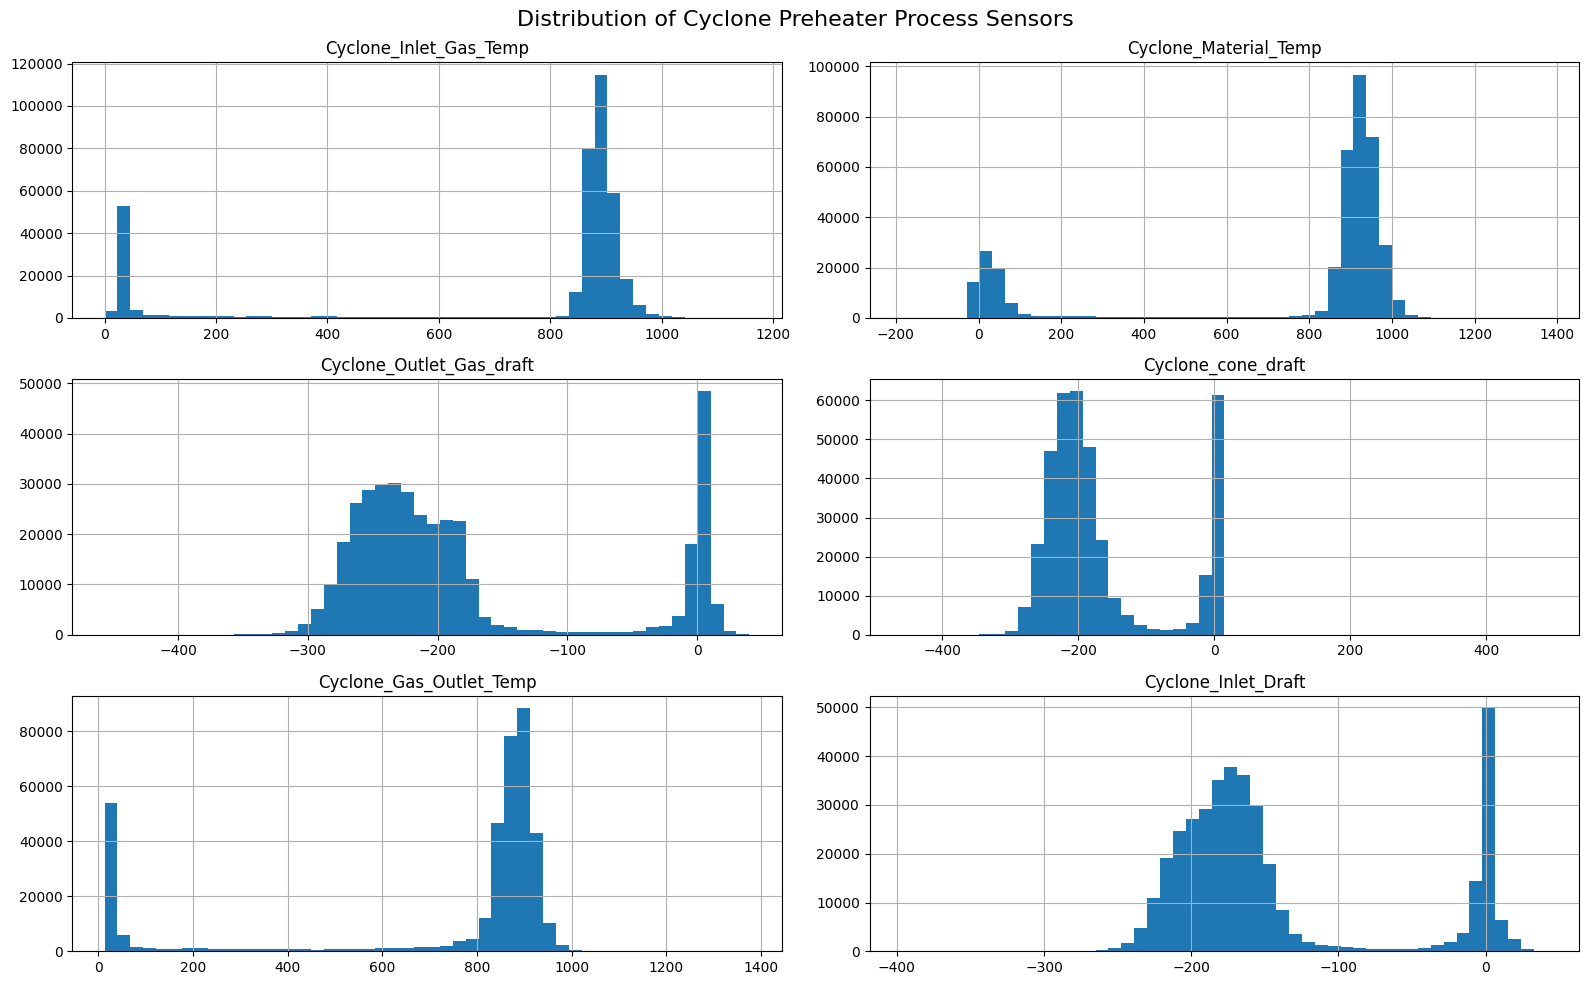

In [ ]:
# --- Visualize sensor distributions ---

process_ts[sensor_cols].hist(
    bins=50,
    figsize=(16, 10)
)

plt.suptitle("Distribution of Cyclone Preheater Process Sensors", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# --- Investigate repeated boundary-like sensor values ---

boundary_values = [0, -185, 1375]

for col in sensor_cols:
    print(f"\n{col}")

    for value in boundary_values:
        count = (process_ts[col] == value).sum()
        if count > 0:
            percentage = count / len(process_ts) * 100
            print(
                f"  Exact value {value}: "
                f"{count} records ({percentage:.3f}%)"
            )


Cyclone_Inlet_Gas_Temp
  Exact value 0: 3 records (0.001%)

Cyclone_Material_Temp
  Exact value 0: 14226 records (3.782%)
  Exact value -185: 49 records (0.013%)
  Exact value 1375: 3 records (0.001%)

Cyclone_Outlet_Gas_draft
  Exact value 0: 47 records (0.012%)
  Exact value -185: 16 records (0.004%)

Cyclone_cone_draft
  Exact value 0: 190 records (0.051%)
  Exact value -185: 32 records (0.009%)

Cyclone_Gas_Outlet_Temp
  Exact value 1375: 24 records (0.006%)

Cyclone_Inlet_Draft
  Exact value 0: 89 records (0.024%)
  Exact value -185: 32 records (0.009%)


In [ ]:
# --- Examine the process state when material temperature is zero ---

material_zero = process_ts["Cyclone_Material_Temp"] == 0

zero_state_summary = process_ts.loc[
    material_zero, sensor_cols
].describe().T

print("Other sensor behavior when Material Temperature = 0:")
display(zero_state_summary)

Other sensor behavior when Material Temperature = 0:


,count,mean,std,min,25%,50%,75%,max
Cyclone_Inlet_Gas_Temp,14226.0,61.437526,140.127124,22.79,29.50,31.225,33.48,1027.23
Cyclone_Material_Temp,14226.0,0.000000,0.000000,0.00,0.00,0.000,0.00,0.00
Cyclone_Outlet_Gas_draft,14226.0,-2.692649,34.781884,-290.78,1.45,2.145,4.80,38.11
Cyclone_cone_draft,14226.0,-6.108872,31.890359,-281.74,-0.75,-0.440,-0.10,15.07
Cyclone_Gas_Outlet_Temp,14226.0,60.921285,137.233111,25.69,29.95,31.500,33.33,1024.49
Cyclone_Inlet_Draft,14226.0,-6.061712,26.822493,-231.87,-2.02,-1.650,-1.32,32.78


In [ ]:
# --- Identify continuous low-load periods ---

low_load_mask = process_ts["Cyclone_Material_Temp"] == 0

low_load = process_ts.loc[low_load_mask, ["time"]].copy()

low_load["new_period"] = (
    low_load["time"].diff().ne(pd.Timedelta(minutes=5))
).fillna(True)

low_load["period"] = low_load["new_period"].cumsum()

low_load_summary = low_load.groupby("period").agg(
    start_time=("time", "min"),
    end_time=("time", "max"),
    records=("time", "size")
)

low_load_summary["duration"] = (
    low_load_summary["end_time"] -
    low_load_summary["start_time"]
)

print("Number of low-load periods:", len(low_load_summary))

print("\nLongest low-load periods:")
display(
    low_load_summary
    .sort_values("records", ascending=False)
    .head(15)
)

Number of low-load periods: 336

Longest low-load periods:


,start_time,end_time,records,duration
period,,,,
74,2017-09-26 10:05:00,2017-09-28 11:30:00,594,2 days 01:25:00
73,2017-09-24 09:30:00,2017-09-26 09:55:00,582,2 days 00:25:00
71,2017-09-22 12:30:00,2017-09-23 17:50:00,353,1 days 05:20:00
70,2017-09-21 11:55:00,2017-09-22 12:00:00,290,1 days 00:05:00
46,2017-08-10 00:00:00,2017-08-10 23:55:00,288,0 days 23:55:00
216,2019-09-10 00:00:00,2019-09-10 23:55:00,288,0 days 23:55:00
204,2019-07-10 00:00:00,2019-07-10 23:55:00,288,0 days 23:55:00
219,2019-10-10 00:00:00,2019-10-10 23:55:00,288,0 days 23:55:00
203,2019-06-10 00:00:00,2019-06-10 23:55:00,288,0 days 23:55:00


In [ ]:
# --- Validate the low-load regime across all process sensors ---

low_load_profile = process_ts.loc[
    low_load_mask, sensor_cols
].median()

overall_profile = process_ts[sensor_cols].median()

comparison = pd.DataFrame({
    "Overall_Median": overall_profile,
    "Low_Load_Median": low_load_profile
})

comparison["Relative_Level"] = (
    comparison["Low_Load_Median"] /
    comparison["Overall_Median"].replace(0, np.nan)
)

print("Overall vs low-load sensor behavior:")
display(comparison.round(3))

Overall vs low-load sensor behavior:


,Overall_Median,Low_Load_Median,Relative_Level
Cyclone_Inlet_Gas_Temp,882.38,31.225,0.035
Cyclone_Material_Temp,913.36,0.000,0.000
Cyclone_Outlet_Gas_draft,-215.26,2.145,-0.010
Cyclone_cone_draft,-198.57,-0.440,0.002
Cyclone_Gas_Outlet_Temp,871.53,31.500,0.036
Cyclone_Inlet_Draft,-169.46,-1.650,0.010


In [ ]:
# ============================================================
# STEP 5: BASELINE MULTIVARIATE ANOMALY DETECTION
# ============================================================

from sklearn.ensemble import IsolationForest

# Low-load operation is treated as a separate operating regime,
# not automatically as an abnormal condition.
active_mask = ~low_load_mask

X_active = process_ts.loc[active_mask, sensor_cols]

print("Active operating records:", len(X_active))
print("Low-load records excluded from anomaly model:", low_load_mask.sum())

# Isolation Forest identifies observations that are unusual
# compared with the overall multivariate operating pattern.
iso_forest = IsolationForest(
    n_estimators=200,
    max_samples=10000,
    contamination="auto",
    random_state=42,
    n_jobs=-1
)

# Train the model on active operating data
iso_forest.fit(X_active)

# Higher score = more anomalous
process_ts["anomaly_score"] = np.nan
process_ts.loc[active_mask, "anomaly_score"] = (
    -iso_forest.score_samples(X_active)
)

print("\nAnomaly score summary:")
display(
    process_ts.loc[active_mask, "anomaly_score"]
    .describe()
)

Active operating records: 361898
Low-load records excluded from anomaly model: 14226

Anomaly score summary:


,anomaly_score
count,361898.000000
mean,0.386008
std,0.054065
min,0.338972
25%,0.353584
50%,0.366002
75%,0.391367
max,0.779349


Candidate anomaly thresholds:

99.0% threshold = 0.582865 | records = 3619 | percentage = 1.000%
99.5% threshold = 0.608229 | records = 1810 | percentage = 0.500%
99.9% threshold = 0.663816 | records = 362 | percentage = 0.100%


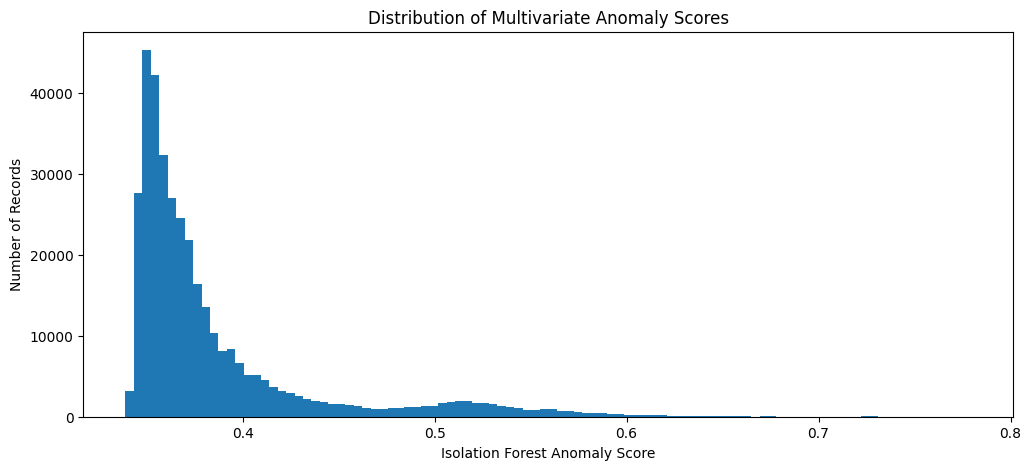

In [ ]:
# ============================================================
# STEP 6: ANOMALY SCORE DISTRIBUTION
# ============================================================

active_scores = process_ts.loc[active_mask, "anomaly_score"]

# Candidate percentile thresholds
thresholds = {
    "99.0%": active_scores.quantile(0.99),
    "99.5%": active_scores.quantile(0.995),
    "99.9%": active_scores.quantile(0.999)
}

print("Candidate anomaly thresholds:\n")

for percentile, threshold in thresholds.items():
    count = (active_scores >= threshold).sum()
    percentage = count / len(active_scores) * 100

    print(
        f"{percentile} threshold = {threshold:.6f} | "
        f"records = {count} | "
        f"percentage = {percentage:.3f}%"
    )

# Plot anomaly score distribution
plt.figure(figsize=(12, 5))

plt.hist(
    active_scores,
    bins=100
)

plt.xlabel("Isolation Forest Anomaly Score")
plt.ylabel("Number of Records")
plt.title("Distribution of Multivariate Anomaly Scores")

plt.show()

In [ ]:
# ============================================================
# STEP 7: REQUIRE AT LEAST 15 MINUTES OF PERSISTENCE
# ============================================================

candidate_results_15min = []

for percentile, threshold in thresholds.items():

    # Identify anomalous observations
    anomaly_flag = (
        process_ts["anomaly_score"] >= threshold
    )

    flagged = process_ts.loc[
        anomaly_flag,
        ["time", "anomaly_score"]
    ].copy()

    # Start a new episode whenever observations are not
    # exactly 5 minutes apart
    flagged["new_episode"] = (
        flagged["time"].diff().ne(pd.Timedelta(minutes=5))
    ).fillna(True)

    flagged["episode"] = flagged["new_episode"].cumsum()

    # Summarize candidate episodes
    episodes = flagged.groupby("episode").agg(
        start_time=("time", "min"),
        end_time=("time", "max"),
        records=("time", "size"),
        max_score=("anomaly_score", "max")
    )

    episodes["duration"] = (
        episodes["end_time"] - episodes["start_time"]
    )

    # Four consecutive observations = 15 minutes elapsed
    persistent = episodes[
        episodes["records"] >= 4
    ].copy()

    candidate_results_15min.append({
        "Threshold": percentile,
        "Raw_anomaly_records": len(flagged),
        "Persistent_periods_15min": len(persistent),
        "Persistent_records": persistent["records"].sum()
    })

candidate_summary_15min = pd.DataFrame(
    candidate_results_15min
)

print("15-minute persistence results:")
display(candidate_summary_15min)

15-minute persistence results:


,Threshold,Raw_anomaly_records,Persistent_periods_15min,Persistent_records
0,99.0%,3619,191,2309
1,99.5%,1810,95,1159
2,99.9%,362,11,215


In [ ]:
# ============================================================
# STEP 8: FINAL ABNORMAL OPERATING PERIODS
# ============================================================

# Final threshold selected from sensitivity analysis
final_threshold = thresholds["99.5%"]

# Flag anomalous observations
final_anomaly_mask = (
    process_ts["anomaly_score"] >= final_threshold
)

flagged_final = process_ts.loc[
    final_anomaly_mask,
    ["time", "anomaly_score"]
].copy()

# Separate anomalies into time-continuous episodes
flagged_final["new_episode"] = (
    flagged_final["time"].diff().ne(
        pd.Timedelta(minutes=5)
    )
).fillna(True)

flagged_final["episode"] = (
    flagged_final["new_episode"].cumsum()
)

# Summarize each episode
abnormal_periods = flagged_final.groupby(
    "episode"
).agg(
    start_time=("time", "min"),
    end_time=("time", "max"),
    records=("time", "size"),
    mean_score=("anomaly_score", "mean"),
    max_score=("anomaly_score", "max")
)

# Duration in minutes
abnormal_periods["duration_minutes"] = (
    abnormal_periods["end_time"]
    - abnormal_periods["start_time"]
).dt.total_seconds() / 60

# Keep only events lasting at least 15 minutes
abnormal_periods = abnormal_periods[
    abnormal_periods["records"] >= 4
].copy()

# Add severity relative to the selected threshold
abnormal_periods["severity_ratio"] = (
    abnormal_periods["max_score"] /
    final_threshold
)

# Rank most severe events first
abnormal_periods = abnormal_periods.sort_values(
    "max_score",
    ascending=False
).reset_index(drop=True)

# Assign clean event IDs
abnormal_periods.insert(
    0,
    "event_id",
    ["ANOM_%03d" % (i + 1)
     for i in range(len(abnormal_periods))]
)

print("Final anomaly threshold:", round(final_threshold, 6))
print("Final abnormal periods:", len(abnormal_periods))
print("Total persistent anomalous records:",
      abnormal_periods["records"].sum())

print("\nTop 20 abnormal operating periods:")
display(
    abnormal_periods.head(20).round(3)
)

Final anomaly threshold: 0.608229
Final abnormal periods: 95
Total persistent anomalous records: 1159

Top 20 abnormal operating periods:


,event_id,start_time,end_time,records,mean_score,max_score,duration_minutes,severity_ratio
0,ANOM_001,2019-08-31 04:40:00,2019-08-31 05:05:00,6,0.736,0.764,25.0,1.256
1,ANOM_002,2019-09-17 01:00:00,2019-09-17 08:15:00,88,0.724,0.732,435.0,1.204
2,ANOM_003,2019-09-16 19:30:00,2019-09-16 23:00:00,43,0.704,0.732,210.0,1.203
3,ANOM_004,2017-11-16 19:15:00,2017-11-16 19:30:00,4,0.679,0.726,15.0,1.194
4,ANOM_005,2017-09-06 02:10:00,2017-09-06 02:50:00,9,0.675,0.713,40.0,1.172
5,ANOM_006,2018-02-24 09:10:00,2018-02-24 09:30:00,5,0.687,0.706,20.0,1.161
6,ANOM_007,2018-02-02 00:00:00,2018-02-02 02:35:00,32,0.672,0.704,155.0,1.157
7,ANOM_008,2018-07-13 22:55:00,2018-07-13 23:55:00,13,0.658,0.703,60.0,1.156
8,ANOM_009,2020-01-29 03:10:00,2020-01-29 03:25:00,4,0.681,0.702,15.0,1.154
9,ANOM_010,2019-03-31 15:50:00,2019-03-31 16:05:00,4,0.687,0.694,15.0,1.142


In [ ]:
# ============================================================
# STEP 9: SENSOR-LEVEL ABNORMALITY INTERPRETATION
# ============================================================

# Calculate robust baseline statistics using active operating data
baseline = {}

for col in sensor_cols:

    values = process_ts.loc[active_mask, col]

    median = values.median()

    # Median Absolute Deviation (MAD)
    mad = np.median(np.abs(values - median))

    baseline[col] = {
        "median": median,
        "mad": mad
    }

# Store event-level sensor deviations
event_sensor_results = []

for _, event in abnormal_periods.iterrows():

    # Select observations belonging to this abnormal period
    event_data = process_ts[
        (process_ts["time"] >= event["start_time"]) &
        (process_ts["time"] <= event["end_time"])
    ]

    result = {
        "event_id": event["event_id"],
        "start_time": event["start_time"],
        "end_time": event["end_time"],
        "duration_minutes": event["duration_minutes"],
        "max_score": event["max_score"]
    }

    sensor_deviations = {}

    for col in sensor_cols:

        event_median = event_data[col].median()

        median = baseline[col]["median"]
        mad = baseline[col]["mad"]

        robust_z = (
            (event_median - median) /
            (1.4826 * mad)
        )

        sensor_deviations[col] = robust_z

        result[f"{col}_robust_z"] = robust_z

    # Identify the sensor with the largest absolute deviation
    dominant_sensor = max(
        sensor_deviations,
        key=lambda x: abs(sensor_deviations[x])
    )

    dominant_z = sensor_deviations[dominant_sensor]

    result["dominant_sensor"] = dominant_sensor
    result["dominant_robust_z"] = dominant_z
    result["dominant_direction"] = (
        "High" if dominant_z > 0 else "Low"
    )

    event_sensor_results.append(result)

event_sensor_summary = pd.DataFrame(
    event_sensor_results
)

print("Sensor-level characterization completed.")

print("\nTop abnormal periods with dominant sensor:")
display(
    event_sensor_summary[
        [
            "event_id",
            "start_time",
            "end_time",
            "duration_minutes",
            "max_score",
            "dominant_sensor",
            "dominant_robust_z",
            "dominant_direction"
        ]
    ].head(20).round(3)
)

Sensor-level characterization completed.

Top abnormal periods with dominant sensor:


,event_id,start_time,end_time,duration_minutes,max_score,dominant_sensor,dominant_robust_z,dominant_direction
0,ANOM_001,2019-08-31 04:40:00,2019-08-31 05:05:00,25.0,0.764,Cyclone_Inlet_Draft,-4.518,Low
1,ANOM_002,2019-09-17 01:00:00,2019-09-17 08:15:00,435.0,0.732,Cyclone_Inlet_Gas_Temp,-29.262,Low
2,ANOM_003,2019-09-16 19:30:00,2019-09-16 23:00:00,210.0,0.732,Cyclone_Inlet_Gas_Temp,-29.121,Low
3,ANOM_004,2017-11-16 19:15:00,2017-11-16 19:30:00,15.0,0.726,Cyclone_Inlet_Draft,-4.235,Low
4,ANOM_005,2017-09-06 02:10:00,2017-09-06 02:50:00,40.0,0.713,Cyclone_Material_Temp,-18.043,Low
5,ANOM_006,2018-02-24 09:10:00,2018-02-24 09:30:00,20.0,0.706,Cyclone_Inlet_Gas_Temp,-26.846,Low
6,ANOM_007,2018-02-02 00:00:00,2018-02-02 02:35:00,155.0,0.704,Cyclone_Inlet_Gas_Temp,-23.145,Low
7,ANOM_008,2018-07-13 22:55:00,2018-07-13 23:55:00,60.0,0.703,Cyclone_Material_Temp,-18.941,Low
8,ANOM_009,2020-01-29 03:10:00,2020-01-29 03:25:00,15.0,0.702,Cyclone_Inlet_Draft,5.533,High
9,ANOM_010,2019-03-31 15:50:00,2019-03-31 16:05:00,15.0,0.694,Cyclone_Inlet_Draft,-3.683,Low


In [ ]:
# ============================================================
# STEP 10: MULTIVARIATE EVENT PROFILING
# ============================================================

# Threshold used to consider an individual sensor
# substantially deviated from its active-operation baseline
sensor_z_threshold = 3

profile_results = []

for _, event in abnormal_periods.iterrows():

    event_data = process_ts[
        (process_ts["time"] >= event["start_time"]) &
        (process_ts["time"] <= event["end_time"])
    ]

    result = {
        "event_id": event["event_id"],
        "start_time": event["start_time"],
        "end_time": event["end_time"],
        "duration_minutes": event["duration_minutes"],
        "max_score": event["max_score"]
    }

    deviations = {}

    # Calculate event-level robust deviation for every sensor
    for col in sensor_cols:

        event_median = event_data[col].median()

        median = baseline[col]["median"]
        mad = baseline[col]["mad"]

        robust_z = (
            (event_median - median) /
            (1.4826 * mad)
        )

        deviations[col] = robust_z

    # Number of substantially deviated sensors
    abnormal_sensor_count = sum(
        abs(z) >= sensor_z_threshold
        for z in deviations.values()
    )

    result["abnormal_sensor_count"] = abnormal_sensor_count

    # Classify the event by how broadly the sensors deviate
    if abnormal_sensor_count >= 4:
        result["event_type"] = "System-wide multivariate deviation"
    elif abnormal_sensor_count >= 2:
        result["event_type"] = "Multi-sensor deviation"
    else:
        result["event_type"] = "Localized sensor deviation"

    # Store the strongest sensor deviation
    dominant_sensor = max(
        deviations,
        key=lambda x: abs(deviations[x])
    )

    result["dominant_sensor"] = dominant_sensor
    result["dominant_robust_z"] = deviations[dominant_sensor]
    result["dominant_direction"] = (
        "High"
        if deviations[dominant_sensor] > 0
        else "Low"
    )

    # Store individual sensor deviations
    for col in sensor_cols:
        result[f"{col}_robust_z"] = deviations[col]

    profile_results.append(result)

event_profile = pd.DataFrame(profile_results)

print("Multivariate event profiling completed.")

print("\nEvent-type distribution:")
display(
    event_profile["event_type"]
    .value_counts()
    .to_frame("events")
)

print("\nTop 20 events:")
display(
    event_profile[
        [
            "event_id",
            "start_time",
            "end_time",
            "duration_minutes",
            "max_score",
            "abnormal_sensor_count",
            "event_type",
            "dominant_sensor",
            "dominant_direction"
        ]
    ].head(20)
)

Multivariate event profiling completed.

Event-type distribution:


,events
event_type,
System-wide multivariate deviation,53
Multi-sensor deviation,22
Localized sensor deviation,20



Top 20 events:


,event_id,start_time,end_time,duration_minutes,max_score,abnormal_sensor_count,event_type,dominant_sensor,dominant_direction
0,ANOM_001,2019-08-31 04:40:00,2019-08-31 05:05:00,25.0,0.763857,3,Multi-sensor deviation,Cyclone_Inlet_Draft,Low
1,ANOM_002,2019-09-17 01:00:00,2019-09-17 08:15:00,435.0,0.732123,3,Multi-sensor deviation,Cyclone_Inlet_Gas_Temp,Low
2,ANOM_003,2019-09-16 19:30:00,2019-09-16 23:00:00,210.0,0.731545,3,Multi-sensor deviation,Cyclone_Inlet_Gas_Temp,Low
3,ANOM_004,2017-11-16 19:15:00,2017-11-16 19:30:00,15.0,0.725970,1,Localized sensor deviation,Cyclone_Inlet_Draft,Low
4,ANOM_005,2017-09-06 02:10:00,2017-09-06 02:50:00,40.0,0.712653,3,Multi-sensor deviation,Cyclone_Material_Temp,Low
5,ANOM_006,2018-02-24 09:10:00,2018-02-24 09:30:00,20.0,0.706044,2,Multi-sensor deviation,Cyclone_Inlet_Gas_Temp,Low
6,ANOM_007,2018-02-02 00:00:00,2018-02-02 02:35:00,155.0,0.703529,6,System-wide multivariate deviation,Cyclone_Inlet_Gas_Temp,Low
7,ANOM_008,2018-07-13 22:55:00,2018-07-13 23:55:00,60.0,0.703244,1,Localized sensor deviation,Cyclone_Material_Temp,Low
8,ANOM_009,2020-01-29 03:10:00,2020-01-29 03:25:00,15.0,0.702065,4,System-wide multivariate deviation,Cyclone_Inlet_Draft,High
9,ANOM_010,2019-03-31 15:50:00,2019-03-31 16:05:00,15.0,0.694496,1,Localized sensor deviation,Cyclone_Inlet_Draft,Low


In [ ]:
# ============================================================
# STEP 11: RECURRING ABNORMAL PATTERNS
# ============================================================

# 1. Dominant sensor frequency
dominant_sensor_counts = (
    event_profile["dominant_sensor"]
    .value_counts()
    .rename("event_count")
    .to_frame()
)

dominant_sensor_counts["percentage"] = (
    dominant_sensor_counts["event_count"]
    / len(event_profile) * 100
)

print("Dominant sensor across abnormal periods:")
display(
    dominant_sensor_counts.round(2)
)

# 2. Direction of dominant deviations
direction_counts = (
    event_profile["dominant_direction"]
    .value_counts()
    .rename("event_count")
    .to_frame()
)

direction_counts["percentage"] = (
    direction_counts["event_count"]
    / len(event_profile) * 100
)

print("\nDominant deviation direction:")
display(
    direction_counts.round(2)
)

# 3. Event type × direction
pattern_table = pd.crosstab(
    event_profile["event_type"],
    event_profile["dominant_direction"]
)

print("\nEvent type by dominant direction:")
display(pattern_table)

# 4. Longest abnormal periods
longest_events = (
    event_profile
    .sort_values("duration_minutes", ascending=False)
    [
        [
            "event_id",
            "start_time",
            "end_time",
            "duration_minutes",
            "max_score",
            "event_type",
            "dominant_sensor",
            "dominant_direction"
        ]
    ]
    .head(15)
)

print("\nLongest abnormal periods:")
display(longest_events.round(2))

Dominant sensor across abnormal periods:


,event_count,percentage
dominant_sensor,,
Cyclone_Inlet_Gas_Temp,43,45.26
Cyclone_Material_Temp,25,26.32
Cyclone_Inlet_Draft,16,16.84
Cyclone_Gas_Outlet_Temp,6,6.32
Cyclone_cone_draft,4,4.21
Cyclone_Outlet_Gas_draft,1,1.05



Dominant deviation direction:


,event_count,percentage
dominant_direction,,
Low,73,76.84
High,22,23.16



Event type by dominant direction:


dominant_direction,High,Low
event_type,,
Localized sensor deviation,1,19
Multi-sensor deviation,9,13
System-wide multivariate deviation,12,41



Longest abnormal periods:


,event_id,start_time,end_time,duration_minutes,max_score,event_type,dominant_sensor,dominant_direction
20,ANOM_021,2019-02-08 15:00:00,2019-02-08 23:55:00,535.0,0.67,System-wide multivariate deviation,Cyclone_Inlet_Gas_Temp,Low
1,ANOM_002,2019-09-17 01:00:00,2019-09-17 08:15:00,435.0,0.73,Multi-sensor deviation,Cyclone_Inlet_Gas_Temp,Low
40,ANOM_041,2018-05-06 15:55:00,2018-05-06 20:30:00,275.0,0.65,System-wide multivariate deviation,Cyclone_Inlet_Gas_Temp,Low
50,ANOM_051,2018-08-29 20:20:00,2018-08-30 00:15:00,235.0,0.64,System-wide multivariate deviation,Cyclone_Inlet_Gas_Temp,Low
2,ANOM_003,2019-09-16 19:30:00,2019-09-16 23:00:00,210.0,0.73,Multi-sensor deviation,Cyclone_Inlet_Gas_Temp,Low
11,ANOM_012,2019-03-08 03:00:00,2019-03-08 06:05:00,185.0,0.69,Multi-sensor deviation,Cyclone_Inlet_Gas_Temp,Low
37,ANOM_038,2018-01-02 18:15:00,2018-01-02 21:05:00,170.0,0.65,System-wide multivariate deviation,Cyclone_Inlet_Gas_Temp,Low
6,ANOM_007,2018-02-02 00:00:00,2018-02-02 02:35:00,155.0,0.70,System-wide multivariate deviation,Cyclone_Inlet_Gas_Temp,Low
52,ANOM_053,2018-07-15 21:15:00,2018-07-15 23:35:00,140.0,0.64,Localized sensor deviation,Cyclone_Inlet_Gas_Temp,Low
41,ANOM_042,2020-03-22 21:05:00,2020-03-22 23:15:00,130.0,0.65,System-wide multivariate deviation,Cyclone_Material_Temp,Low


In [ ]:
# ============================================================
# STEP 12: TEMPORAL PATTERN ANALYSIS
# ============================================================

temporal_events = event_profile.copy()

# Extract calendar/time information
temporal_events["year"] = (
    temporal_events["start_time"].dt.year
)

temporal_events["month"] = (
    temporal_events["start_time"].dt.month
)

temporal_events["hour"] = (
    temporal_events["start_time"].dt.hour
)

# ------------------------------------------------------------
# 1. Events by year
# ------------------------------------------------------------

events_by_year = (
    temporal_events["year"]
    .value_counts()
    .sort_index()
    .rename("event_count")
    .to_frame()
)

print("Abnormal events by year:")
display(events_by_year)

# ------------------------------------------------------------
# 2. Events by month
# ------------------------------------------------------------

events_by_month = (
    temporal_events["month"]
    .value_counts()
    .sort_index()
    .rename("event_count")
    .to_frame()
)

print("\nAbnormal events by month:")
display(events_by_month)

# ------------------------------------------------------------
# 3. Events by hour
# ------------------------------------------------------------

events_by_hour = (
    temporal_events["hour"]
    .value_counts()
    .sort_index()
    .rename("event_count")
    .to_frame()
)

print("\nAbnormal events by hour:")
display(events_by_hour)

# ------------------------------------------------------------
# 4. Duration statistics
# ------------------------------------------------------------

duration_summary = temporal_events[
    "duration_minutes"
].describe()

print("\nAbnormal-event duration statistics:")
display(duration_summary.to_frame("duration_minutes").round(2))

Abnormal events by year:


,event_count
year,
2017,15
2018,48
2019,26
2020,6



Abnormal events by month:


,event_count
month,
1,9
2,7
3,13
4,6
5,10
6,12
7,6
8,6
9,12



Abnormal events by hour:


,event_count
hour,
0,5
1,5
2,3
3,3
4,2
5,1
6,1
7,3
8,6



Abnormal-event duration statistics:


,duration_minutes
count,95.00
mean,56.00
std,80.63
min,15.00
25%,17.50
50%,25.00
75%,60.00
max,535.00


In [ ]:
# ============================================================
# STEP 13: FINAL ABNORMAL PERIOD DATASET
# ============================================================

# Select the useful analytical columns
final_events = event_profile[
    [
        "event_id",
        "start_time",
        "end_time",
        "duration_minutes",
        "max_score",
        "abnormal_sensor_count",
        "event_type",
        "dominant_sensor",
        "dominant_robust_z",
        "dominant_direction"
    ]
].copy()

# Add mean anomaly score from the original event table
final_events = final_events.merge(
    abnormal_periods[
        [
            "event_id",
            "mean_score",
            "severity_ratio"
        ]
    ],
    on="event_id",
    how="left"
)

# Sort chronologically for the final report
final_events = final_events.sort_values(
    "start_time"
).reset_index(drop=True)

print("Final abnormal-period dataset:")
print("Number of events:", len(final_events))

display(final_events.head(20))

Final abnormal-period dataset:
Number of events: 95


,event_id,start_time,end_time,duration_minutes,max_score,abnormal_sensor_count,event_type,dominant_sensor,dominant_robust_z,dominant_direction,mean_score,severity_ratio
0,ANOM_068,2017-02-03 02:05:00,2017-02-03 02:20:00,15.0,0.631236,4,System-wide multivariate deviation,Cyclone_Inlet_Draft,4.844744,High,0.623755,1.037827
1,ANOM_080,2017-02-11 16:05:00,2017-02-11 16:20:00,15.0,0.623448,1,Localized sensor deviation,Cyclone_Material_Temp,-22.570878,Low,0.618240,1.025022
2,ANOM_050,2017-03-23 06:25:00,2017-03-23 07:25:00,60.0,0.643211,4,System-wide multivariate deviation,Cyclone_Inlet_Gas_Temp,-9.850511,Low,0.620734,1.057514
3,ANOM_028,2017-03-25 03:15:00,2017-03-25 03:35:00,20.0,0.661650,2,Multi-sensor deviation,Cyclone_Inlet_Gas_Temp,-9.448352,Low,0.653631,1.087830
4,ANOM_055,2017-03-30 20:55:00,2017-03-30 22:05:00,70.0,0.638059,2,Multi-sensor deviation,Cyclone_Inlet_Draft,4.587141,High,0.636013,1.049045
5,ANOM_032,2017-05-30 20:35:00,2017-05-30 21:15:00,40.0,0.655726,5,System-wide multivariate deviation,Cyclone_Inlet_Gas_Temp,-10.976489,Low,0.637980,1.078091
6,ANOM_037,2017-06-16 19:55:00,2017-06-16 20:20:00,25.0,0.654330,4,System-wide multivariate deviation,Cyclone_Inlet_Draft,3.980621,High,0.629004,1.075796
7,ANOM_005,2017-09-06 02:10:00,2017-09-06 02:50:00,40.0,0.712653,3,Multi-sensor deviation,Cyclone_Material_Temp,-18.043353,Low,0.674860,1.171685
8,ANOM_025,2017-09-19 00:45:00,2017-09-19 02:00:00,75.0,0.664016,4,System-wide multivariate deviation,Cyclone_Material_Temp,5.373022,High,0.642051,1.091720
9,ANOM_004,2017-11-16 19:15:00,2017-11-16 19:30:00,15.0,0.725970,1,Localized sensor deviation,Cyclone_Inlet_Draft,-4.234517,Low,0.678834,1.193580


In [ ]:
# Save the final abnormal-period report
output_file = "/content/abnormal_periods.csv"

final_events.to_csv(
    output_file,
    index=False
)

print("Saved successfully:")
print(output_file)

Saved successfully:
/content/abnormal_periods.csv


In [ ]:
# ============================================================
# STEP 15: PCA-BASED MULTIVARIATE VALIDATION
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Use active operating data only
X_active = process_ts.loc[active_mask, sensor_cols]

# Standardize sensors because they have different scales
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_active)

# PCA retains the main multivariate operating structure
pca = PCA(n_components=0.95, random_state=42)

X_pca = pca.fit_transform(X_scaled)

# Reconstruct the original standardized observations
X_reconstructed = pca.inverse_transform(X_pca)

# Reconstruction error = distance from learned process structure
reconstruction_error = np.mean(
    (X_scaled - X_reconstructed) ** 2,
    axis=1
)

# Store PCA error in the main dataframe
process_ts["pca_reconstruction_error"] = np.nan

process_ts.loc[
    active_mask,
    "pca_reconstruction_error"
] = reconstruction_error

print("PCA validation completed.")

print("\nNumber of PCA components explaining 95% variance:",
      pca.n_components_)

print("\nExplained variance ratio:")
print(
    np.round(
        pca.explained_variance_ratio_,
        4
    )
)

print("\nCumulative explained variance:")
print(
    np.round(
        np.cumsum(pca.explained_variance_ratio_),
        4
    )
)

print("\nPCA reconstruction-error summary:")
display(
    process_ts.loc[
        active_mask,
        "pca_reconstruction_error"
    ].describe()
)

PCA validation completed.

Number of PCA components explaining 95% variance: 2

Explained variance ratio:
[0.9294 0.0516]

Cumulative explained variance:
[0.9294 0.981 ]

PCA reconstruction-error summary:


,pca_reconstruction_error
count,361898.000000
mean,0.019011
std,0.067386
min,0.000005
25%,0.002204
50%,0.006142
75%,0.014493
max,5.722490


In [ ]:
# ============================================================
# STEP 16: VALIDATE ISOLATION FOREST EVENTS WITH PCA
# ============================================================

# Overall PCA reconstruction-error statistics
active_pca_error = process_ts.loc[
    active_mask,
    "pca_reconstruction_error"
]

pca_median = active_pca_error.median()
pca_95 = active_pca_error.quantile(0.95)
pca_99 = active_pca_error.quantile(0.99)

print("Overall PCA reconstruction-error baseline:")
print("Median:", round(pca_median, 6))
print("95th percentile:", round(pca_95, 6))
print("99th percentile:", round(pca_99, 6))

# Calculate PCA error statistics for every detected event
pca_event_results = []

for _, event in final_events.iterrows():

    event_data = process_ts[
        (process_ts["time"] >= event["start_time"]) &
        (process_ts["time"] <= event["end_time"])
    ]

    event_errors = event_data[
        "pca_reconstruction_error"
    ].dropna()

    pca_event_results.append({
        "event_id": event["event_id"],
        "mean_pca_error": event_errors.mean(),
        "max_pca_error": event_errors.max(),
        "pca_error_95th": event_errors.quantile(0.95)
    })

pca_event_validation = pd.DataFrame(
    pca_event_results
)

# Merge PCA validation results
final_events = final_events.merge(
    pca_event_validation,
    on="event_id",
    how="left"
)

# Determine whether the event's mean PCA error
# is above the overall 95th percentile
final_events["pca_validated"] = (
    final_events["mean_pca_error"] >= pca_95
)

print("\nPCA validation of detected events:")
display(
    final_events[
        [
            "event_id",
            "max_score",
            "mean_pca_error",
            "max_pca_error",
            "pca_validated"
        ]
    ].head(20).round(4)
)

print("\nPCA validation summary:")

validated_count = final_events["pca_validated"].sum()
total_events = len(final_events)

print(
    f"Events above PCA 95th-percentile baseline: "
    f"{validated_count}/{total_events}"
)

print(
    "Validation percentage:",
    round(validated_count / total_events * 100, 2),
    "%"
)

Overall PCA reconstruction-error baseline:
Median: 0.006142
95th percentile: 0.060057
99th percentile: 0.212014

PCA validation of detected events:


,event_id,max_score,mean_pca_error,max_pca_error,pca_validated
0,ANOM_068,0.6312,0.0150,0.0240,False
1,ANOM_080,0.6234,1.2597,1.2993,True
2,ANOM_050,0.6432,0.0929,0.1208,True
3,ANOM_028,0.6616,0.0684,0.1258,True
4,ANOM_055,0.6381,0.2408,0.3241,True
5,ANOM_032,0.6557,0.0280,0.1296,False
6,ANOM_037,0.6543,0.0194,0.0251,False
7,ANOM_005,0.7127,0.6326,0.8750,True
8,ANOM_025,0.6640,0.0541,0.0850,False
9,ANOM_004,0.7260,0.0456,0.0620,False



PCA validation summary:
Events above PCA 95th-percentile baseline: 47/95
Validation percentage: 49.47 %


In [ ]:
# ============================================================
# STEP 16A: SAVE ENRICHED FINAL EVENT REPORT
# ============================================================

final_events.to_csv(
    "/content/abnormal_periods.csv",
    index=False
)

print("Updated abnormal-period report saved successfully.")
print("Events:", len(final_events))
print("Columns:", len(final_events.columns))

print("\nFinal columns:")
print(final_events.columns.tolist())

Updated abnormal-period report saved successfully.
Events: 95
Columns: 16

Final columns:
['event_id', 'start_time', 'end_time', 'duration_minutes', 'max_score', 'abnormal_sensor_count', 'event_type', 'dominant_sensor', 'dominant_robust_z', 'dominant_direction', 'mean_score', 'severity_ratio', 'mean_pca_error', 'max_pca_error', 'pca_error_95th', 'pca_validated']


# Final Industrial Insights and Recommendations

## Key Findings

### 1. Most anomalies are process-level, not isolated sensor deviations
Out of 95 detected abnormal periods, 53 (55.79%) were classified as system-wide multivariate deviations and 22 (23.16%) as multi-sensor deviations. Therefore, 75 of 95 events (78.95%) involved multiple abnormal sensors.

**Industrial implication:** The detected events frequently represent coordinated changes in the cyclone preheater process rather than isolated sensor fluctuations. Such events should receive higher priority for process investigation.

### 2. Temperature variables are the dominant contributors
Cyclone Inlet Gas Temperature was the dominant sensor in 43 events, followed by Cyclone Material Temperature in 25 events. Together, these temperature variables accounted for 68 of 95 events (71.58%).

**Industrial implication:** Temperature-related process variables should be closely monitored when investigating abnormal operating periods.

### 3. Persistence helps distinguish operationally meaningful events
The anomaly detector initially identified point-level deviations, but a persistence requirement of at least 15 minutes was applied to reduce isolated transient spikes. The final analysis identified 95 persistent abnormal periods.

Most events were relatively short, with a median duration of 25 minutes. However, some events persisted for several hours, with the longest event lasting 535 minutes.

**Industrial implication:** Persistent anomalies can be prioritized over isolated spikes because sustained abnormal behavior is more relevant for operational investigation.

### 4. The anomaly pattern is predominantly low-direction
Among the detected events, 73 (76.84%) had a dominant sensor deviation in the low direction, while 22 (23.16%) were high-direction deviations.

**Industrial implication:** Investigation should particularly examine operating conditions associated with unusually low temperature or draft behavior.

### 5. PCA provides independent multivariate validation
PCA reconstruction error was used as a secondary validation method rather than as a replacement for Isolation Forest. 47 of the 95 detected events (49.47%) exceeded the PCA 95th-percentile reconstruction-error reference.

**Industrial implication:** The two methods capture complementary forms of abnormality. Isolation Forest identifies unusual observations in the multivariate feature space, while PCA highlights deviations from the dominant multivariate structure.

## Recommended Operational Response

1. Prioritize persistent system-wide and multi-sensor events for investigation.
2. Monitor Cyclone Inlet Gas Temperature and Cyclone Material Temperature closely.
3. Review prolonged low-direction anomaly periods against operational logs, maintenance records, and production conditions.
4. Use the abnormal-period report as an investigation queue rather than treating every anomaly as a confirmed equipment failure.
5. In a production deployment, combine anomaly alerts with maintenance, production, quality, and process-context data to support root-cause analysis.
6. Establish feedback from confirmed operator investigations so that future anomaly detection thresholds and models can be refined.

## Important Limitation

The dataset does not contain confirmed failure, maintenance, quality-loss, or root-cause labels. Therefore, the detected events should be interpreted as **statistically abnormal operating periods requiring investigation**, not as confirmed equipment failures or specific root causes.

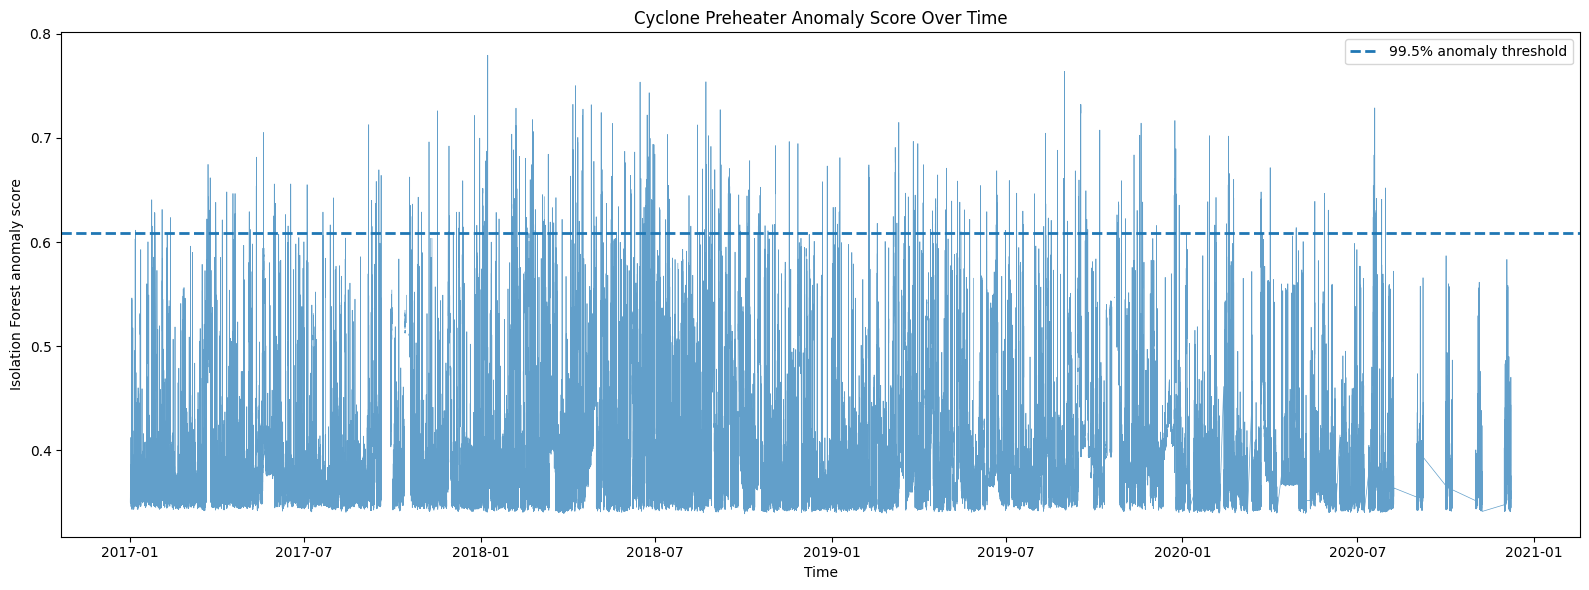

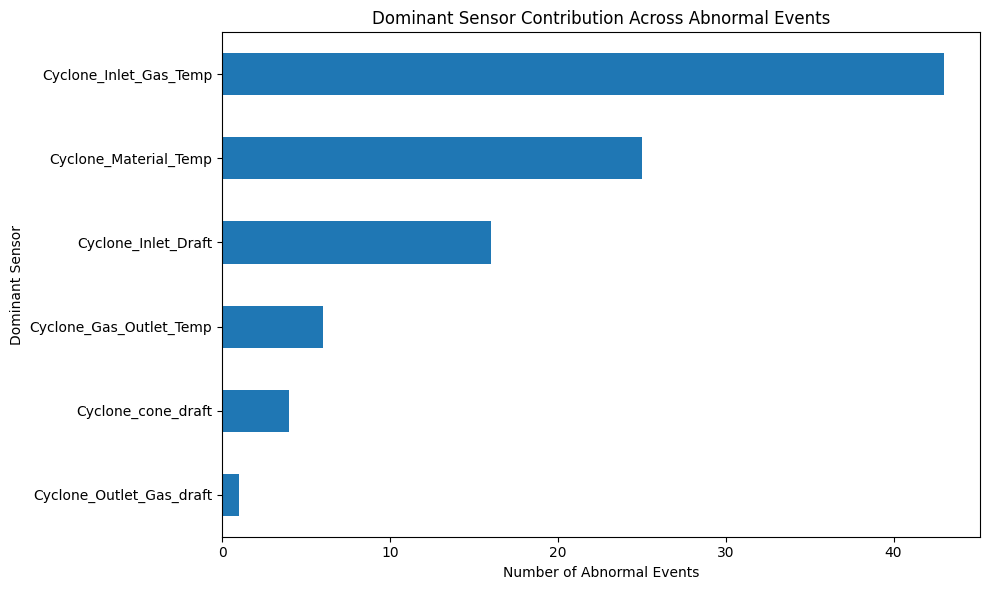

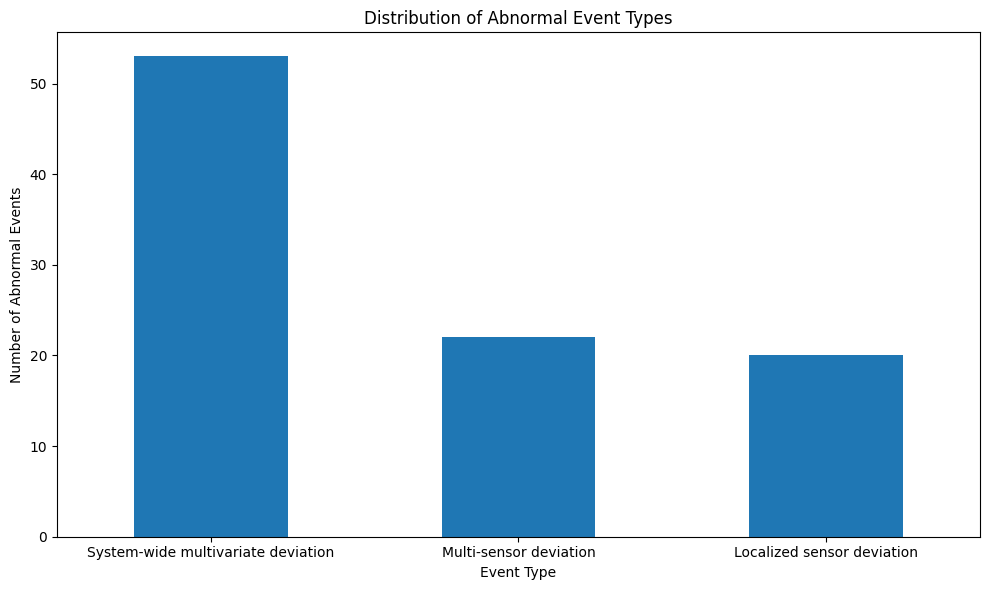

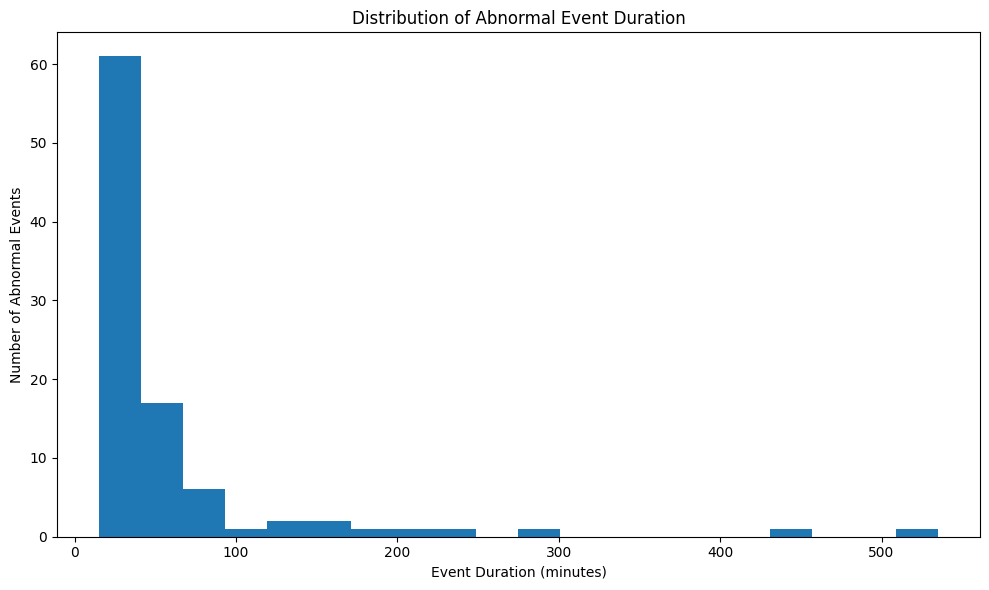

Final visualization files saved:
1. anomaly_score_timeline.png
2. dominant_sensor_contribution.png
3. event_type_distribution.png
4. abnormal_event_duration.png


In [ ]:
# STEP 17 — Save Final Visualizations for PPT

# 1. Anomaly Score Timeline
plt.figure(figsize=(16, 6))
plt.plot(
    process_ts["time"],
    process_ts["anomaly_score"],
    linewidth=0.5,
    alpha=0.7
)
plt.axhline(
    final_threshold,
    linestyle="--",
    linewidth=2,
    label="99.5% anomaly threshold"
)
plt.xlabel("Time")
plt.ylabel("Isolation Forest anomaly score")
plt.title("Cyclone Preheater Anomaly Score Over Time")
plt.legend()
plt.tight_layout()
plt.savefig("/content/anomaly_score_timeline.png", dpi=300, bbox_inches="tight")
plt.show()


# 2. Dominant Sensor Contribution
sensor_counts = final_events["dominant_sensor"].value_counts().sort_values()

plt.figure(figsize=(10, 6))
sensor_counts.plot(kind="barh")
plt.xlabel("Number of Abnormal Events")
plt.ylabel("Dominant Sensor")
plt.title("Dominant Sensor Contribution Across Abnormal Events")
plt.tight_layout()
plt.savefig("/content/dominant_sensor_contribution.png", dpi=300, bbox_inches="tight")
plt.show()


# 3. Event Type Distribution
event_type_counts = final_events["event_type"].value_counts()

plt.figure(figsize=(10, 6))
event_type_counts.plot(kind="bar")
plt.xlabel("Event Type")
plt.ylabel("Number of Abnormal Events")
plt.title("Distribution of Abnormal Event Types")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("/content/event_type_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


# 4. Abnormal Event Duration
plt.figure(figsize=(10, 6))
plt.hist(
    final_events["duration_minutes"],
    bins=20
)
plt.xlabel("Event Duration (minutes)")
plt.ylabel("Number of Abnormal Events")
plt.title("Distribution of Abnormal Event Duration")
plt.tight_layout()
plt.savefig("/content/abnormal_event_duration.png", dpi=300, bbox_inches="tight")
plt.show()


# Confirm files
print("Final visualization files saved:")
print("1. anomaly_score_timeline.png")
print("2. dominant_sensor_contribution.png")
print("3. event_type_distribution.png")
print("4. abnormal_event_duration.png")

In [ ]:
# STEP 18 — Industrial Investigation Priority Score

priority_df = final_events.copy()

# 1. Normalize anomaly severity
severity_score = (
    priority_df["max_score"] - priority_df["max_score"].min()
) / (
    priority_df["max_score"].max() - priority_df["max_score"].min()
)

# 2. Normalize event duration
duration_score = (
    priority_df["duration_minutes"] - priority_df["duration_minutes"].min()
) / (
    priority_df["duration_minutes"].max() - priority_df["duration_minutes"].min()
)

# 3. Multivariate impact
sensor_score = (
    priority_df["abnormal_sensor_count"] - 1
) / (
    priority_df["abnormal_sensor_count"].max() - 1
)

# 4. PCA validation
pca_score = priority_df["pca_validated"].astype(int)

# Combined investigation priority
priority_df["priority_score"] = (
    0.40 * severity_score +
    0.25 * duration_score +
    0.20 * sensor_score +
    0.15 * pca_score
) * 100

# Priority categories
priority_df["priority_level"] = pd.cut(
    priority_df["priority_score"],
    bins=[-np.inf, 40, 65, np.inf],
    labels=["Low", "Medium", "High"]
)

# Sort highest priority first
priority_df = priority_df.sort_values(
    "priority_score",
    ascending=False
).reset_index(drop=True)

# Save updated report
priority_df.to_csv(
    "/content/abnormal_periods_with_priority.csv",
    index=False
)

print("Investigation priority engine completed.")
print("\nPriority distribution:")
print(priority_df["priority_level"].value_counts())

print("\nTop 15 events requiring investigation:")
print(
    priority_df[
        [
            "event_id",
            "start_time",
            "duration_minutes",
            "event_type",
            "dominant_sensor",
            "max_score",
            "abnormal_sensor_count",
            "pca_validated",
            "priority_score",
            "priority_level"
        ]
    ].head(15).to_string(index=False)
)

print("\nSaved:")
print("/content/abnormal_periods_with_priority.csv")

Investigation priority engine completed.

Priority distribution:
priority_level
Low       77
Medium    17
High       1
Name: count, dtype: int64

Top 15 events requiring investigation:
event_id          start_time  duration_minutes                         event_type         dominant_sensor  max_score  abnormal_sensor_count  pca_validated  priority_score priority_level
ANOM_007 2018-02-02 00:00:00             155.0 System-wide multivariate deviation  Cyclone_Inlet_Gas_Temp   0.703529                      6           True       65.866729           High
ANOM_002 2019-09-17 01:00:00             435.0             Multi-sensor deviation  Cyclone_Inlet_Gas_Temp   0.732123                      3          False       59.847306         Medium
ANOM_021 2019-02-08 15:00:00             535.0 System-wide multivariate deviation  Cyclone_Inlet_Gas_Temp   0.674056                      5          False       57.385489         Medium
ANOM_015 2018-02-09 22:25:00              20.0 System-wide multivariate

In [ ]:
# STEP 19 — Prepare Streamlit Application Files

import joblib

# --------------------------------------------------
# 1. Save trained Isolation Forest model
# --------------------------------------------------

joblib.dump(
    iso_forest,
    "/content/isolation_forest_model.joblib"
)


# --------------------------------------------------
# 2. Create monitoring dataset
# --------------------------------------------------

monitoring_data = process_ts[
    ["time"] + sensor_cols + ["anomaly_score"]
].copy()

# Default anomaly status
monitoring_data["anomaly_flag"] = (
    monitoring_data["anomaly_score"] >= final_threshold
)

# --------------------------------------------------
# 3. Attach abnormal event IDs
# --------------------------------------------------

monitoring_data["event_id"] = None

for _, event in priority_df.iterrows():

    mask = (
        (monitoring_data["time"] >= event["start_time"]) &
        (monitoring_data["time"] <= event["end_time"])
    )

    monitoring_data.loc[mask, "event_id"] = event["event_id"]


# --------------------------------------------------
# 4. Attach priority information
# --------------------------------------------------

priority_columns = [
    "event_id",
    "priority_score",
    "priority_level",
    "event_type",
    "dominant_sensor",
    "dominant_direction",
    "duration_minutes",
    "abnormal_sensor_count",
    "pca_validated"
]

monitoring_data = monitoring_data.merge(
    priority_df[priority_columns],
    on="event_id",
    how="left",
    suffixes=("", "_event")
)


# --------------------------------------------------
# 5. Save monitoring dataset
# --------------------------------------------------

monitoring_data.to_csv(
    "/content/monitoring_data.csv",
    index=False
)


# --------------------------------------------------
# 6. Confirmation
# --------------------------------------------------

print("Dashboard files prepared successfully.\n")

print("1. abnormal_periods_with_priority.csv")
print("2. monitoring_data.csv")
print("3. isolation_forest_model.joblib")

print("\nMonitoring dataset shape:")
print(monitoring_data.shape)

print("\nMonitoring columns:")
print(monitoring_data.columns.tolist())

print("\nAnomalous records:")
print(monitoring_data["anomaly_flag"].sum())

print("\nEvents connected to monitoring data:")
print(monitoring_data["event_id"].notna().sum())

Dashboard files prepared successfully.

1. abnormal_periods_with_priority.csv
2. monitoring_data.csv
3. isolation_forest_model.joblib

Monitoring dataset shape:
(376124, 18)

Monitoring columns:
['time', 'Cyclone_Inlet_Gas_Temp', 'Cyclone_Material_Temp', 'Cyclone_Outlet_Gas_draft', 'Cyclone_cone_draft', 'Cyclone_Gas_Outlet_Temp', 'Cyclone_Inlet_Draft', 'anomaly_score', 'anomaly_flag', 'event_id', 'priority_score', 'priority_level', 'event_type', 'dominant_sensor', 'dominant_direction', 'duration_minutes', 'abnormal_sensor_count', 'pca_validated']

Anomalous records:
1810

Events connected to monitoring data:
1159
